# 01 — Exploratory Data Analysis

RDD2022 India+Japan subset (`data/raw/`). Covers: class distribution,
image resolution spread, bounding-box size distribution, a 12-image
sample mosaic per class, and the class co-occurrence matrix.

Class mapping (see `configs/data.yaml` and
`docs/learning/00-project-overview.md` for the convention-based caveat):
`0=D00 longitudinal crack, 1=D10 transverse crack, 2=D20 alligator crack, 3=D40 pothole`.

In [1]:
import random
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from PIL import Image, ImageDraw
from tqdm import tqdm

sns.set_theme(style="whitegrid")
random.seed(42)

Matplotlib is building the font cache; this may take a moment.


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "data" / "raw"
VIZ_DIR = PROJECT_ROOT / "results" / "visualizations"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / "configs" / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = {int(k): v for k, v in data_cfg["names"].items()}
NUM_CLASSES = data_cfg["nc"]
SPLITS = ["train", "valid", "test"]
CLASS_COLORS = {0: "#e6194b", 1: "#3cb44b", 2: "#4363d8", 3: "#f58231"}

print("Classes:", CLASS_NAMES)
print("Data root:", DATA_ROOT)

Classes: {0: 'D00', 1: 'D10', 2: 'D20', 3: 'D40'}
Data root: C:\Projects\road-damage-detection-yolo\data\raw


## Build annotation-level and image-level tables

One pass over each split: open every image once (header-only read for
resolution), parse its label file, and record both per-box rows
(annotation-level) and one summary row per image (image-level, tracking
which classes are present — needed for the co-occurrence matrix).

In [3]:
def load_split(split):
    images_dir = DATA_ROOT / split / "images"
    labels_dir = DATA_ROOT / split / "labels"
    ann_rows = []
    img_rows = []
    image_paths = sorted(images_dir.glob("*.jpg"))
    for img_path in tqdm(image_paths, desc=f"{split}"):
        label_path = labels_dir / (img_path.stem + ".txt")
        try:
            with Image.open(img_path) as im:
                img_w, img_h = im.size
        except Exception as e:
            print(f"skip unreadable image {img_path.name}: {e}")
            continue

        classes_present = set()
        if label_path.exists():
            lines = [l for l in label_path.read_text().splitlines() if l.strip()]
            for line in lines:
                parts = line.split()
                cls_id = int(parts[0])
                xc, yc, w, h = (float(v) for v in parts[1:5])
                classes_present.add(cls_id)
                ann_rows.append({
                    "split": split,
                    "image": img_path.name,
                    "class_id": cls_id,
                    "class_name": CLASS_NAMES.get(cls_id, str(cls_id)),
                    "img_w": img_w,
                    "img_h": img_h,
                    "box_w_px": w * img_w,
                    "box_h_px": h * img_h,
                })
        img_rows.append({
            "split": split,
            "image": img_path.name,
            "img_w": img_w,
            "img_h": img_h,
            "classes_present": frozenset(classes_present),
            "num_boxes": len(classes_present) if not classes_present else sum(
                1 for l in lines
            ) if label_path.exists() else 0,
        })
    return ann_rows, img_rows


all_ann_rows, all_img_rows = [], []
for split in SPLITS:
    ann_rows, img_rows = load_split(split)
    all_ann_rows.extend(ann_rows)
    all_img_rows.extend(img_rows)

ann_df = pd.DataFrame(all_ann_rows)
img_df = pd.DataFrame(all_img_rows)
print("annotations:", ann_df.shape, " images:", img_df.shape)
ann_df.head()

train:   0%|          | 0/12425 [00:00<?, ?it/s]

train:   0%|          | 3/12425 [00:00<07:37, 27.14it/s]

train:   0%|          | 6/12425 [00:00<23:08,  8.95it/s]

train:   0%|          | 10/12425 [00:00<14:07, 14.64it/s]

train:   0%|          | 16/12425 [00:00<08:34, 24.12it/s]

...

test: 100%|█████████▉| 1114/1117 [00:28<00:00, 27.98it/s]

test: 100%|██████████| 1117/1117 [00:28<00:00, 27.93it/s]

test: 100%|██████████| 1117/1117 [00:28<00:00, 38.71it/s]

annotations: (18638, 8)  images: (14594, 6)


,split,image,class_id,class_name,img_w,img_h,box_w_px,box_h_px
0,train,India_000005.jpg,3,D40,720,720,347.976,103.032
1,train,India_000027.jpg,3,D40,720,720,112.032,50.976
2,train,India_000027.jpg,3,D40,720,720,79.992,37.008
3,train,India_000027.jpg,3,D40,720,720,109.008,76.968
4,train,India_000027.jpg,3,D40,720,720,166.968,86.976


## 1. Class Distribution

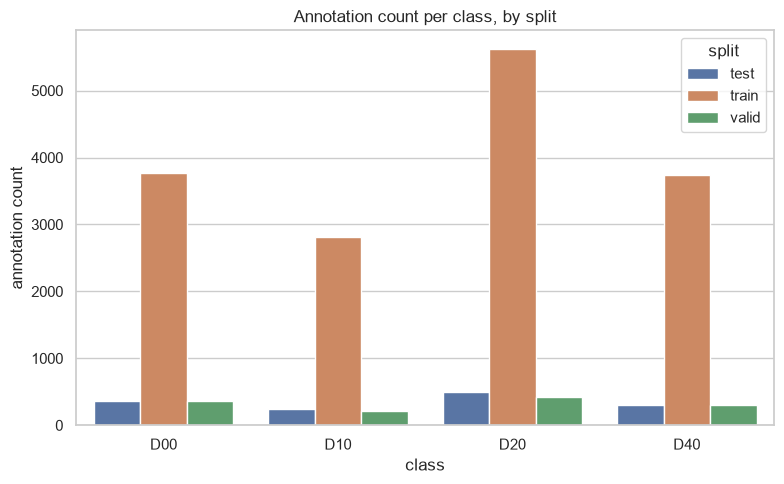

split,test,train,valid
class_name,,,
D00,363,3767,362
D10,236,2814,210
D20,504,5617,421
D40,305,3740,299


In [4]:
counts = (
    ann_df.groupby(["split", "class_name"]).size().reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=counts, x="class_name", y="count", hue="split",
            order=[CLASS_NAMES[i] for i in range(NUM_CLASSES)], ax=ax)
ax.set_title("Annotation count per class, by split")
ax.set_xlabel("class")
ax.set_ylabel("annotation count")
fig.tight_layout()
fig.savefig(VIZ_DIR / "class_distribution.png", dpi=150)
plt.show()

counts.pivot(index="class_name", columns="split", values="count").fillna(0).astype(int)

## 2. Image Resolution Histogram

5 distinct resolutions across 14594 images


,img_w,img_h,count
1,600,600,8141
2,720,720,6188
3,1024,1024,124
0,540,540,102
4,1080,1080,39


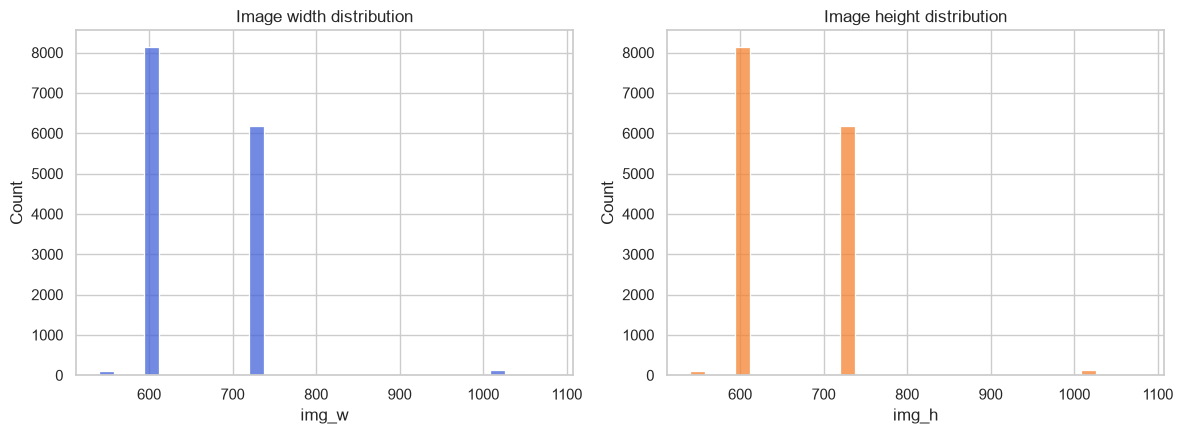

In [5]:
res_counts = (
    img_df.groupby(["img_w", "img_h"]).size().reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(f"{len(res_counts)} distinct resolutions across {len(img_df)} images")
display(res_counts.head(15))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(img_df["img_w"], bins=30, ax=axes[0], color="#4363d8")
axes[0].set_title("Image width distribution")
sns.histplot(img_df["img_h"], bins=30, ax=axes[1], color="#f58231")
axes[1].set_title("Image height distribution")
fig.tight_layout()
fig.savefig(VIZ_DIR / "resolution_histogram.png", dpi=150)
plt.show()

## 3. BBox Size Heatmap

Box width vs. height in pixels (converted from normalized YOLO coords
using each image's actual resolution), across all annotations.

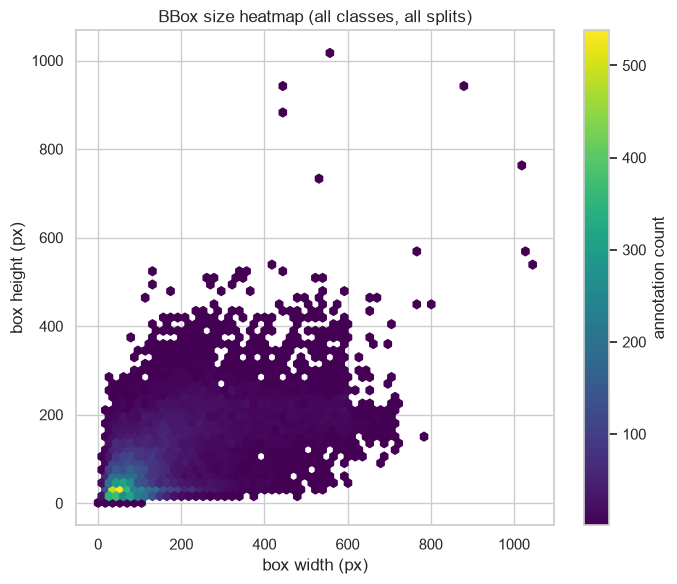

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
hb = ax.hexbin(ann_df["box_w_px"], ann_df["box_h_px"], gridsize=60,
               cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=ax, label="annotation count")
ax.set_xlabel("box width (px)")
ax.set_ylabel("box height (px)")
ax.set_title("BBox size heatmap (all classes, all splits)")
fig.tight_layout()
fig.savefig(VIZ_DIR / "bbox_size_heatmap.png", dpi=150)
plt.show()

## 4. Sample Mosaic — 12 images per class

For each class, sample 12 images (train split) containing at least one
box of that class, draw only that class's boxes, and lay out a 3x4 grid.

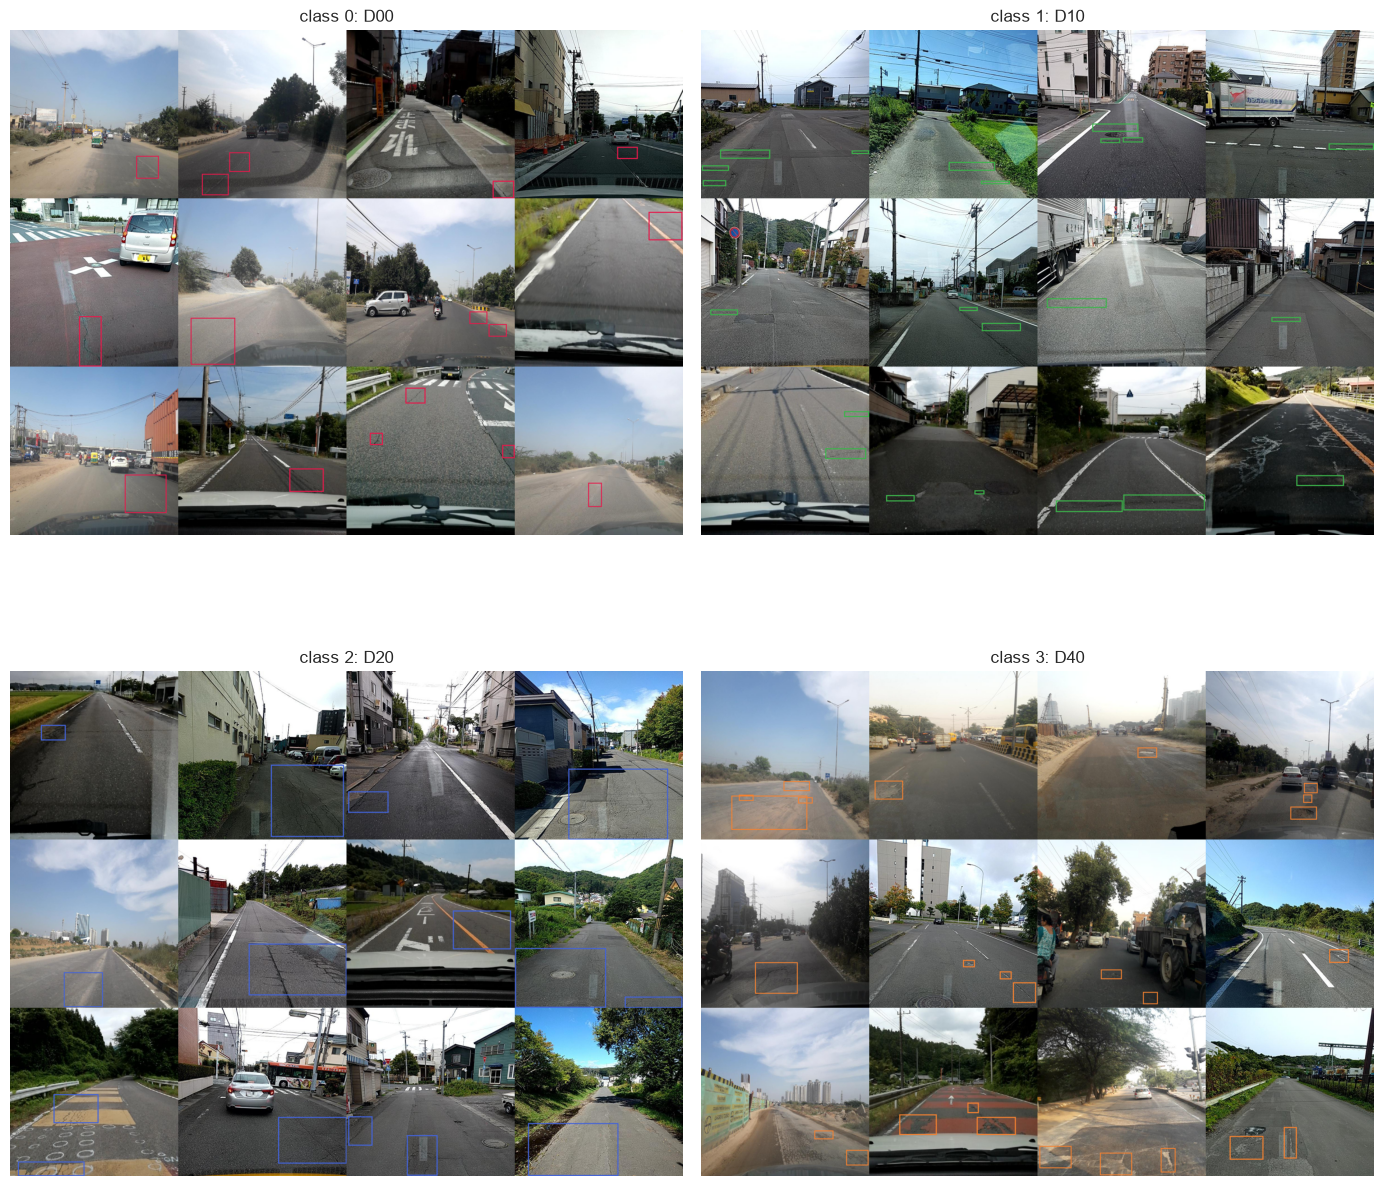

In [7]:
THUMB = 300

def draw_class_boxes(img_path, label_path, target_class):
    im = Image.open(img_path).convert("RGB")
    img_w, img_h = im.size
    draw = ImageDraw.Draw(im)
    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        cls_id = int(parts[0])
        if cls_id != target_class:
            continue
        xc, yc, w, h = (float(v) for v in parts[1:5])
        x0, y0 = (xc - w / 2) * img_w, (yc - h / 2) * img_h
        x1, y1 = (xc + w / 2) * img_w, (yc + h / 2) * img_h
        draw.rectangle([x0, y0, x1, y1], outline=CLASS_COLORS[target_class], width=4)
    return im.resize((THUMB, THUMB))


def build_mosaic(target_class, n=12, cols=4):
    candidates = img_df[
        (img_df["split"] == "train")
        & img_df["classes_present"].apply(lambda s: target_class in s)
    ]["image"].tolist()
    sample = random.sample(candidates, min(n, len(candidates)))
    rows = -(-len(sample) // cols)
    mosaic = Image.new("RGB", (cols * THUMB, rows * THUMB), "white")
    labels_dir = DATA_ROOT / "train" / "labels"
    images_dir = DATA_ROOT / "train" / "images"
    for i, name in enumerate(sample):
        thumb = draw_class_boxes(images_dir / name, labels_dir / (Path(name).stem + ".txt"), target_class)
        r, c = divmod(i, cols)
        mosaic.paste(thumb, (c * THUMB, r * THUMB))
    return mosaic


fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, cls_id in zip(axes.flat, range(NUM_CLASSES)):
    mosaic = build_mosaic(cls_id)
    mosaic.save(VIZ_DIR / f"mosaic_class_{cls_id}_{CLASS_NAMES[cls_id]}.png")
    ax.imshow(mosaic)
    ax.set_title(f"class {cls_id}: {CLASS_NAMES[cls_id]}")
    ax.axis("off")
fig.tight_layout()
fig.savefig(VIZ_DIR / "class_mosaics_grid.png", dpi=150)
plt.show()

## 5. Class Co-occurrence Matrix

How often each pair of classes appears together within the same image
(diagonal = images containing that class at all, regardless of what else
is in the image).

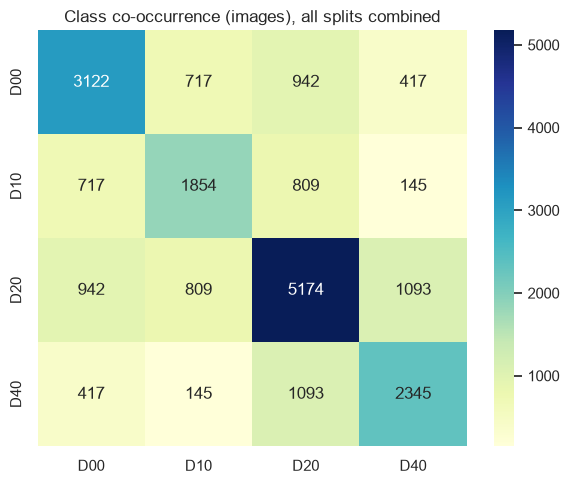

,D00,D10,D20,D40
D00,3122,717,942,417
D10,717,1854,809,145
D20,942,809,5174,1093
D40,417,145,1093,2345


In [8]:
co_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for classes_present in img_df["classes_present"]:
    if not classes_present:
        continue
    for c in classes_present:
        co_matrix[c, c] += 1
    for c1, c2 in combinations(sorted(classes_present), 2):
        co_matrix[c1, c2] += 1
        co_matrix[c2, c1] += 1

labels = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
co_df = pd.DataFrame(co_matrix, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(co_df, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Class co-occurrence (images), all splits combined")
fig.tight_layout()
fig.savefig(VIZ_DIR / "class_cooccurrence_matrix.png", dpi=150)
plt.show()
co_df